In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
df = pd.read_csv("C:\\Users\\njap\\Downloads\\4406040.csv")

In [28]:
df.head()

,STATION,NAME,DATE,AWND,FMTM,PGTM,PRCP,PSUN,SNOW,SNWD,...,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22
0,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",2010-01-01,5.14,1551.0,1514.0,0.0,NaN,0.0,0.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",2010-01-02,8.50,1325.0,1324.0,0.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",2010-01-03,7.16,1600.0,1601.0,0.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",2010-01-04,7.16,2000.0,2000.0,0.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",2010-01-05,6.71,1632.0,1516.0,0.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df.columns

Index(['STATION', 'NAME', 'DATE', 'AWND', 'FMTM', 'PGTM', 'PRCP', 'PSUN',
       'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TSUN', 'WDF2', 'WDF5', 'WESD',
       'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT07',
       'WT08', 'WT09', 'WT11', 'WT13', 'WT14', 'WT15', 'WT16', 'WT17', 'WT18',
       'WT19', 'WT21', 'WT22'],
      dtype='object')

In [ ]:
df["DATE"] = pd.to_datetime(df["DATE"])        
df = df.sort_values("DATE").set_index("DATE")

rain = df["PRCP"]                             
rain = rain.asfreq("D")
print(rain.isna().sum(), "missing days of", len(rain)) # Check for missing rainfall data

0 missing days of 5418


In [ ]:
print(rain.describe())
print("Average yearly total:", round(rain.sum() / (len(rain) / 365.25), 1)) # To see if it's mm or inches

count    5418.000000
mean        0.125751
std         0.352536
min         0.000000
25%         0.000000
50%         0.000000
75%         0.037500
max         4.620000
Name: PRCP, dtype: float64
Average yearly total: 45.9


In [33]:
data = pd.DataFrame(index=rain.index)

# the last 28 days
for k in range(1, 29):
    data[f"lag_{k}"] = rain.shift(k - 1)

# 7-day averages ending today
roll7 = rain.rolling(7).mean()
for j in range(4):
    data[f"roll7_t-{7*j}"] = roll7.shift(7 * j)

# Seasonality
doy = data.index.dayofyear
data["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
data["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

# total rain over the NEXT 7 days
data["target"] = rain.rolling(7).sum().shift(-7)

data = data.dropna()
print(len(data), "usable rows")



5384 usable rows


In [34]:
split = int(len(data) * 0.8)
train, test = data.iloc[:split - 7], data.iloc[split:]   # 7-day gap avoids overlap

seasonal = ["doy_sin", "doy_cos"]
feature_sets = {
    "Raw daily (28 lags)":    [f"lag_{k}" for k in range(1, 29)] + seasonal,
    "Rolling 7-day (4 avgs)": [f"roll7_t-{7*j}" for j in range(4)] + seasonal,
}

results, preds, models = {}, {}, {}
for name, cols in feature_sets.items():
    m = LinearRegression().fit(train[cols], train["target"])
    p = np.clip(m.predict(test[cols]), 0, None)          # no negative rainfall
    models[name], preds[name] = m, p
    results[name] = {"MAE": mean_absolute_error(test["target"], p),
                     "RMSE": np.sqrt(mean_squared_error(test["target"], p)),
                     "R2": r2_score(test["target"], p)}

pd.DataFrame(results).T.round(3)

,MAE,RMSE,R2
Raw daily (28 lags),0.781,1.038,-0.023
Rolling 7-day (4 avgs),0.781,1.038,-0.022


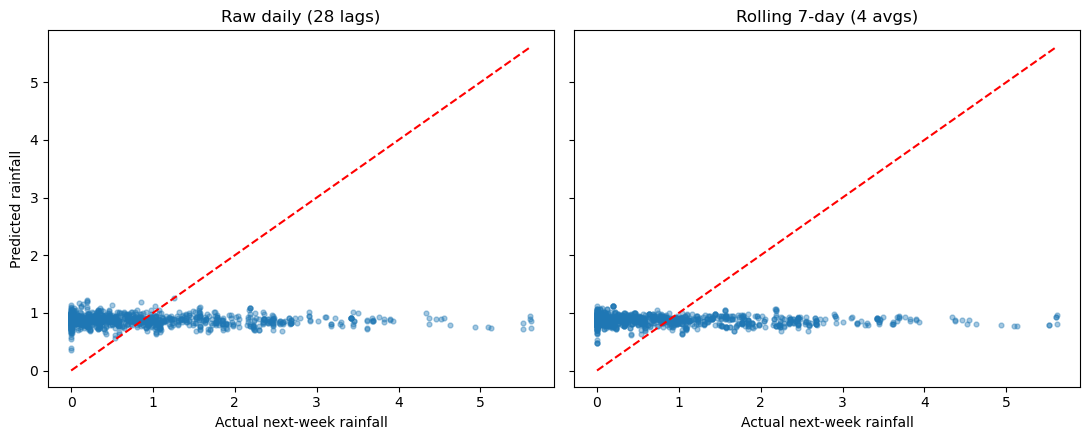

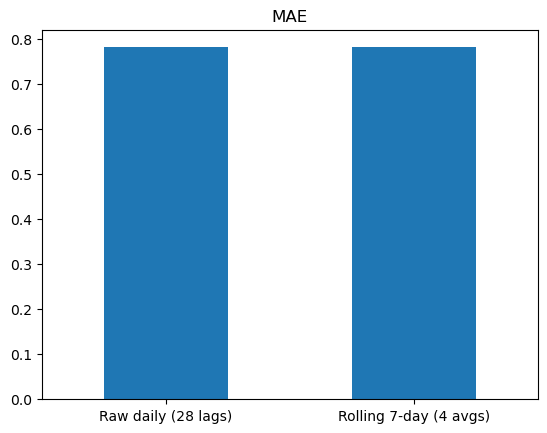

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (name, p) in zip(axes, preds.items()):
    ax.scatter(test["target"], p, alpha=0.4, s=12)
    lim = [0, max(test["target"].max(), p.max())]
    ax.plot(lim, lim, "r--")
    ax.set_title(name)
    ax.set_xlabel("Actual next-week rainfall")
axes[0].set_ylabel("Predicted rainfall")
plt.tight_layout(); plt.show()

# Error comparison
pd.DataFrame(results).T["MAE"].plot(kind="bar", rot=0, title="MAE")
plt.show()

In [37]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_results, rf_preds, rf_models = {}, {}, {}

for name, cols in feature_sets.items():
    rf = RandomForestRegressor(n_estimators=300,      
                               min_samples_leaf=5,    
                               random_state=42,       
                               n_jobs=-1)             
    rf.fit(train[cols], train["target"])
    p = rf.predict(test[cols])
    rf_models[name], rf_preds[name] = rf, p
    rf_results[name] = {"MAE": mean_absolute_error(test["target"], p),
                        "RMSE": np.sqrt(mean_squared_error(test["target"], p)),
                        "R2": r2_score(test["target"], p)}

pd.DataFrame(rf_results).T.round(3)

,MAE,RMSE,R2
Raw daily (28 lags),0.777,1.04,-0.027
Rolling 7-day (4 avgs),0.763,1.04,-0.027


In [40]:
linear_table = pd.DataFrame(results).T
linear_table.index = [f"Linear: {i}" for i in linear_table.index]

rf_table = pd.DataFrame(rf_results).T
rf_table.index = [f"Random forest: {i}" for i in rf_table.index]

base = np.full(len(test), train["target"].mean())
baseline_table = pd.DataFrame({"MAE": [mean_absolute_error(test["target"], base)],
                               "RMSE": [np.sqrt(mean_squared_error(test["target"], base))],
                               "R2": [r2_score(test["target"], base)]},
                              index=["Baseline: training average"])

all_results = pd.concat([baseline_table, linear_table, rf_table])
all_results.round(3)

,MAE,RMSE,R2
Baseline: training average,0.771,1.027,-0.001
Linear: Raw daily (28 lags),0.781,1.038,-0.023
Linear: Rolling 7-day (4 avgs),0.781,1.038,-0.022
Random forest: Raw daily (28 lags),0.777,1.040,-0.027
Random forest: Rolling 7-day (4 avgs),0.763,1.040,-0.027


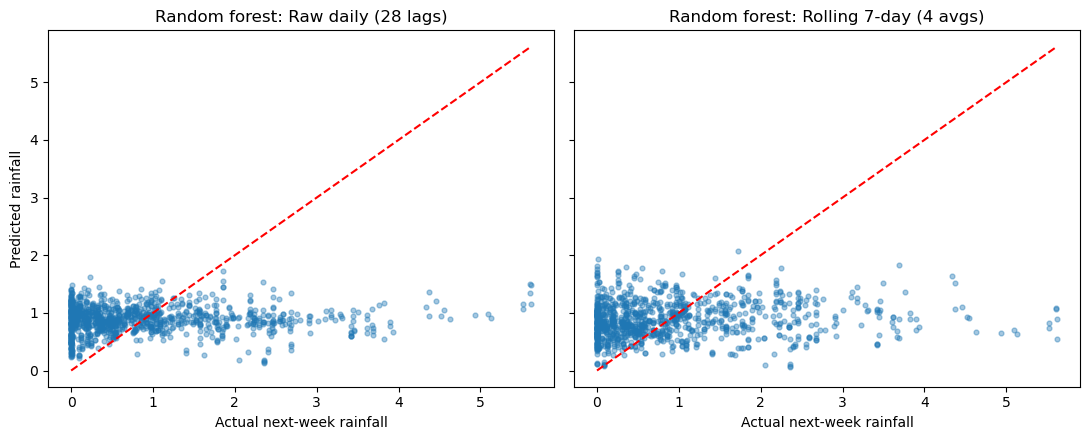

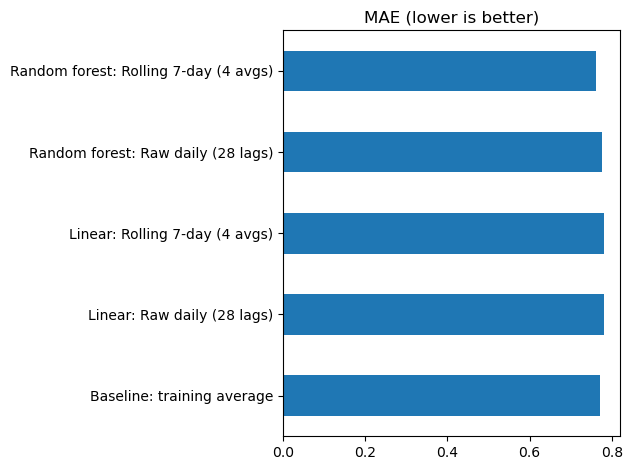

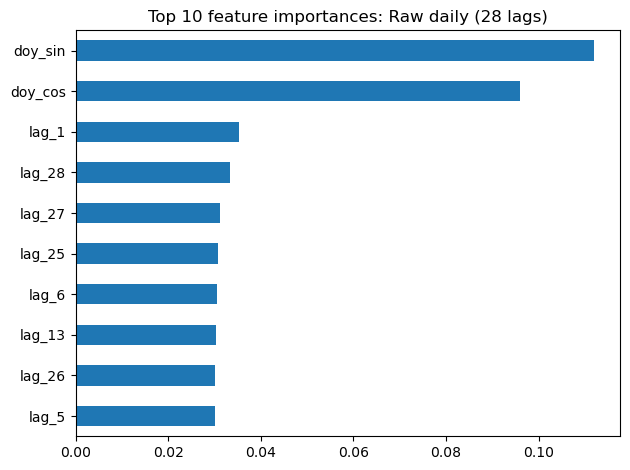

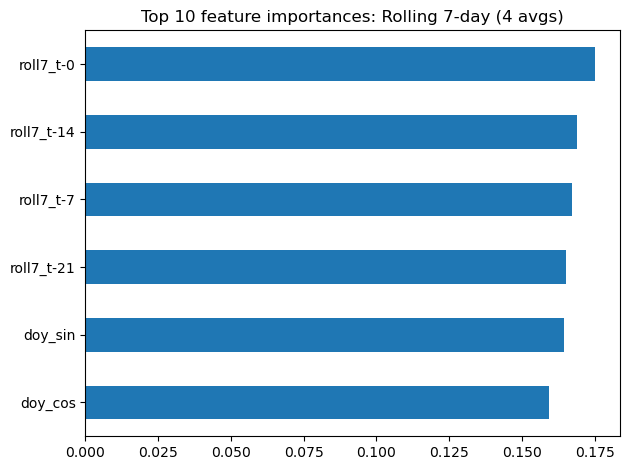

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (name, p) in zip(axes, rf_preds.items()):
    ax.scatter(test["target"], p, alpha=0.4, s=12)
    lim = [0, max(test["target"].max(), p.max())]
    ax.plot(lim, lim, "r--")
    ax.set_title("Random forest: " + name)
    ax.set_xlabel("Actual next-week rainfall")
axes[0].set_ylabel("Predicted rainfall")
plt.tight_layout(); plt.show()

# MAE for all models 
all_results["MAE"].plot(kind="barh", title="MAE (lower is better)")
plt.tight_layout(); plt.show()

for name, cols in feature_sets.items():
    imp = pd.Series(rf_models[name].feature_importances_, index=cols).sort_values().tail(10)
    imp.plot(kind="barh", title=f"Top 10 feature importances: {name}")
    plt.tight_layout(); plt.show()

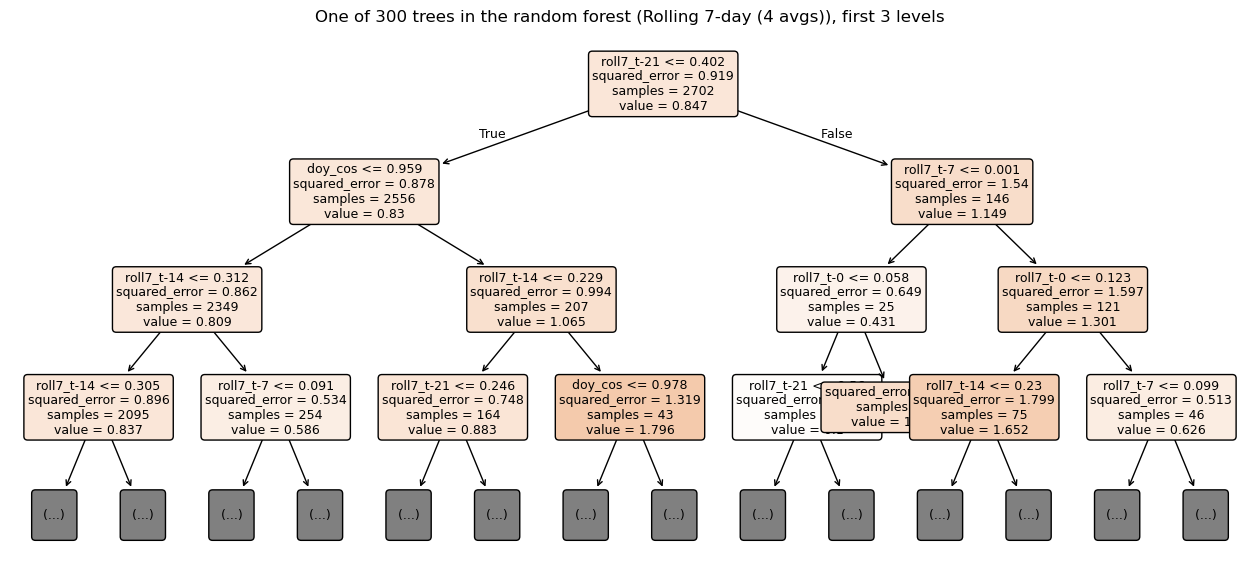

In [ ]:
from sklearn.tree import plot_tree

name = "Rolling 7-day (4 avgs)"          
cols = feature_sets[name]
one_tree = rf_models[name].estimators_[0] 

plt.figure(figsize=(16, 7))
plot_tree(one_tree, feature_names=cols, max_depth=3, filled=True, rounded=True, fontsize=9)
plt.title(f"One of {len(rf_models[name].estimators_)} trees in the random forest ({name}), first 3 levels")
plt.show()